In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import re 
import joblib
import string

In [5]:
fake = pd.read_csv('Fake.csv')
true = pd.read_csv('True.csv')

In [6]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [7]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [8]:
fake['class']=0
true['class']=1

In [9]:
df = pd.concat([fake,true], axis = 0)

In [10]:
df.sample(10)

,title,text,subject,date,class
12088,Christmas market opens in Algerian capital,ALGIERS (Reuters) - A small Christmas market h...,worldnews,"December 17, 2017",1
5929,New U.S. U.N. envoy warns allies: back us or w...,UNITED NATIONS (Reuters) - The new U.S. ambass...,politicsNews,"January 27, 2017",1
8916,John McCain Goes Full-On Birther — Tries To G...,It s no secret that Senator John McCain hates ...,News,"January 7, 2016",0
4655,Israel's Netanyahu pledges to work with Trump ...,WASHINGTON (Reuters) - Israeli Prime Minister ...,politicsNews,"March 27, 2017",1
11407,WOOHOO! NEVER TRUMPER Tells Why He’s Jumpin’ o...,When you bring #NeverTrumper @greggutfeld on-b...,politics,"Mar 14, 2017",0
21232,Several wounded after blast hits bus in Turkey...,ANKARA (Reuters) - Seven people were wounded w...,worldnews,"August 31, 2017",1
9086,COORDINATED? Yet Another Hack Reporter Claims ...,A coordinated effort to spew anti-Trump propag...,politics,"Dec 31, 2017",0
8575,Donald Trump Just Told His Fans They’re Stupi...,Donald Trump s heavily-conservative base is fi...,News,"January 23, 2016",0
22274,REVEALED: The Establishment’s Scheme to Take D...,21st Century Wire says Based on the events we ...,US_News,"January 14, 2017",0
15977,Tribal blockade in Peru's oil block lifted aft...,LIMA (Reuters) - Indigenous villagers ended a ...,worldnews,"November 1, 2017",1


In [11]:
df= df.drop(["title","subject","date"], axis = 1)

In [12]:
df.reset_index(inplace=True)

In [13]:
df.drop(['index'],axis = 1,inplace=True)

In [14]:
df.sample(5)

,text,class
38659,ISTANBUL (Reuters) - Turkish police detained 1...,1
34718,LONDON (Reuters) - U.S. Republican presidentia...,1
40302,DUBAI (Reuters) - An Iranian vessel with 19 sa...,1
36151,LONDON (Reuters) - British voters will be able...,1
26211,WASHINGTON (Reuters) - Donald Trump’s campaign...,1


In [17]:
def clean_text(text):
    text = text.lower()
    text =re.sub("\\W"," ",text)
    text =re.sub("<.*?>+","",text)
    text =re.sub("[%s]" % re.escape(string.punctuation),"",text)
    text =re.sub("\n","",text)
    return text

In [18]:
df["text"] = df["text"].apply(clean_text)

In [19]:
x=df["text"]
y=df["class"]

xtrain, xtest, ytrain, ytest =train_test_split(x,y,test_size=0.25,random_state=42)

In [20]:
vectorizer = TfidfVectorizer()
xv_train = vectorizer.fit_transform(xtrain)
xv_test = vectorizer.transform(xtest)

In [21]:
lr = LogisticRegression()
lr.fit(xv_train,ytrain)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [22]:
prediction = lr.predict(xv_test)
lr.score(xv_test,ytest)

0.9860133630289533

In [23]:
print(classification_report(ytest,prediction))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      5895
           1       0.98      0.99      0.99      5330

    accuracy                           0.99     11225
   macro avg       0.99      0.99      0.99     11225
weighted avg       0.99      0.99      0.99     11225



In [24]:
# Week 3: Model Building
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [25]:
knn = KNeighborsClassifier(n_neighbors=5)
logreg = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=100)

MLPClassifier(
hidden_layer_sizes=(50,),
max_iter=100
)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50,)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",None


In [26]:
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=100
)

In [ ]:
X = df["text"]

y = df["class"]

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(X)

In [29]:
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Naive Bayes": MultinomialNB(),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42)

}

In [33]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

results = []

for name, model in models.items():

    model.fit(xtrain, ytrain)

    y_pred = model.predict(xtest)

    accuracy = accuracy_score(ytest, y_pred)

    precision = precision_score(ytest, y_pred)

    recall = recall_score(ytest, y_pred)

    f1 = f1_score(ytest, y_pred)

    results.append([

        name,

        accuracy,

        precision,

        recall,

        f1

    ])

results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1-score"

    ]

)

results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.986971,0.985197,0.987285,0.986240
1,Naive Bayes,0.931849,0.933667,0.921356,0.927471
2,Decision Tree,0.995880,0.995294,0.995997,0.995646
3,Random Forest,0.996771,0.996703,0.996468,0.996585


C:\Users\HP\AppData\Local\Temp\ipykernel_292\1090142893.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


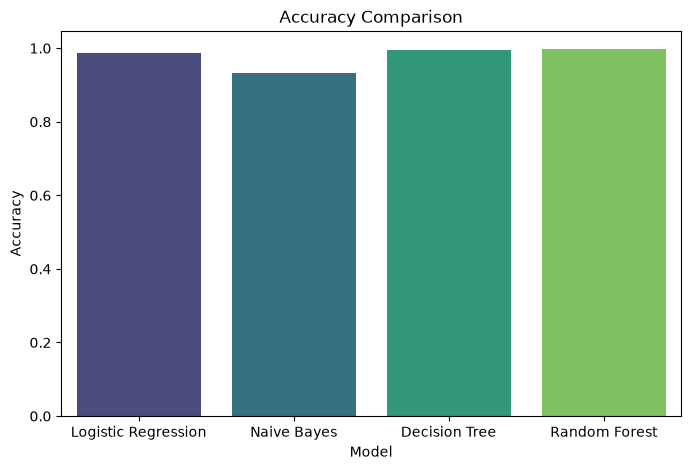

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(

    data=results_df,

    x="Model",

    y="Accuracy",

    palette="viridis"

)

plt.title("Accuracy Comparison")

plt.show()

In [38]:
joblib.dump(vectorizer,"vectorizer.jb")
joblib.dump(lr,"lr_model.jb")

['lr_model.jb']